# Uncertainty forecasting on a public labor-market dataset

This notebook applies the probabilistic extension of the signature-transform framework to **U.S. initial jobless claims in levels**. Uncertainty is modeled through weighted quantile regression on top of signature features and adaptive signature-kernel weights. As in notebook 3, the target remains in levels, while the model forecasts **future changes over each horizon** and then converts those forecasts back into level predictions and prediction intervals.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd

from marketplace_signature_forecast.config import (
    ALL_HORIZONS,
    DEFAULT_DEPTH,
    DEFAULT_N_TARGET,
    DEFAULT_WINDOW_SIZE,
    FRED_API_KEY,
)
from marketplace_signature_forecast.data_loading import (
    build_data_dictionary_from_specs,
    fetch_series_bundle,
)
from marketplace_signature_forecast.dataset_specs import (
    INITIAL_CLAIMS_END_DATE,
    INITIAL_CLAIMS_EXPERIMENT_NAME,
    INITIAL_CLAIMS_FRED_INPUTS,
    INITIAL_CLAIMS_N_VALIDATION,
    INITIAL_CLAIMS_PLOT_HORIZON,
    INITIAL_CLAIMS_RESAMPLE_FREQ,
    INITIAL_CLAIMS_START_DATE,
    INITIAL_CLAIMS_TARGET,
    INITIAL_CLAIMS_YAHOO_INPUTS,
)
from marketplace_signature_forecast.preprocessing import (
    build_model_dataset,
    prepare_standardized_arrays,
    resample_collection,
    resample_to_weekly,
    save_processed_bundle,
    train_validation_split,
)
from marketplace_signature_forecast.evaluation import run_multi_horizon_experiment
from marketplace_signature_forecast.plotting import plot_quantile_forecast_interval
from marketplace_signature_forecast.quantile_evaluation import run_multi_horizon_quantile_experiment

TARGET_COL = INITIAL_CLAIMS_TARGET["name"]
TARGET_LABEL = INITIAL_CLAIMS_TARGET["name"]
PUBLIC_EXPERIMENT_NAME = INITIAL_CLAIMS_EXPERIMENT_NAME

BASE_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / f"{PUBLIC_EXPERIMENT_NAME}_uncertainty"
DATASET_DIR = BASE_OUTPUT_DIR / "dataset"
Y_ONLY_DIR = BASE_OUTPUT_DIR / "signature_y_only_quantiles"
JOINT_DIR = BASE_OUTPUT_DIR / "signature_joint_path_quantiles"
POINT_Y_ONLY_DIR = BASE_OUTPUT_DIR / "point_y_only"
POINT_JOINT_DIR = BASE_OUTPUT_DIR / "point_joint_path"
PLOT_DIR = PROJECT_ROOT / "figures" / f"{PUBLIC_EXPERIMENT_NAME}_uncertainty"

for directory in [BASE_OUTPUT_DIR, DATASET_DIR, Y_ONLY_DIR, JOINT_DIR, POINT_Y_ONLY_DIR, POINT_JOINT_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.1, 0.5, 0.9]
QUANTILE_ALPHA = 1e-2
WINDOW_SIZE = DEFAULT_WINDOW_SIZE
DEPTH = DEFAULT_DEPTH
N_TARGET = DEFAULT_N_TARGET
ADD_TIME = True

data_dictionary = build_data_dictionary_from_specs(
    target=INITIAL_CLAIMS_TARGET,
    fred_inputs=INITIAL_CLAIMS_FRED_INPUTS,
    yahoo_inputs=INITIAL_CLAIMS_YAHOO_INPUTS,
)
target_mask = data_dictionary["type"].eq("target (y)")
data_dictionary.loc[target_mask, "variable"] = TARGET_COL
data_dictionary.loc[target_mask, "description"] = "U.S. initial jobless claims in levels"
data_dictionary.loc[target_mask, "frequency"] = "Weekly, ending Saturday"
data_dictionary.loc[target_mask, "code"] = INITIAL_CLAIMS_TARGET["code"]
data_dictionary

,variable,type,source,code,description,frequency
0,initial_claims,target (y),FRED,ICSA,U.S. initial jobless claims in levels,"Weekly, ending Saturday"
1,continued_claims,input (x),FRED,CCSA,Continued Claims (Insured Unemployment),"Weekly, Ending Saturday"
2,nfci,input (x),FRED,NFCI,Chicago Fed National Financial Conditions Index,Weekly
3,vix,input (x),FRED,VIXCLS,CBOE Volatility Index,Daily
4,term_spread,input (x),FRED,T10Y2Y,10-Year Treasury Constant Maturity Minus 2-Yea...,Daily
5,sp500,input (x),FRED,SP500,S&P 500 Index,Daily
6,wti_crude,input (x),FRED,DCOILWTICO,WTI Crude Oil Spot Price,Daily
7,effr,input (x),FRED,FEDFUNDS,Effective Federal Funds Rate,Monthly


## 1. Rebuild the weekly public dataset

The public experiment uses the same raw FRED series as notebook 2. The target remains in **levels**, and the uncertainty-forecasting pipeline models **future changes over horizon $h$** before mapping the quantile forecasts back into level-space prediction intervals.

In [2]:
y_raw, x_raw = fetch_series_bundle(
    api_key=FRED_API_KEY,
    target=INITIAL_CLAIMS_TARGET,
    start=INITIAL_CLAIMS_START_DATE,
    end=INITIAL_CLAIMS_END_DATE,
    fred_inputs=INITIAL_CLAIMS_FRED_INPUTS,
    yahoo_inputs=INITIAL_CLAIMS_YAHOO_INPUTS,
)

y_weekly = resample_to_weekly(y_raw, freq=INITIAL_CLAIMS_RESAMPLE_FREQ)
y_target = y_weekly.rename(columns={INITIAL_CLAIMS_TARGET["name"]: TARGET_COL})

x_weekly = resample_collection(x_raw, freq=INITIAL_CLAIMS_RESAMPLE_FREQ)
full_data = build_model_dataset(y_target, x_weekly).dropna().copy()
train_data, validation_data = train_validation_split(full_data, INITIAL_CLAIMS_N_VALIDATION)

save_processed_bundle(full_data, train_data, validation_data, data_dictionary, DATASET_DIR)

print(full_data.shape)
print(full_data.index.min(), full_data.index.max())
full_data.head()

(105, 8)
2016-04-02 00:00:00 2024-12-07 00:00:00


,initial_claims,continued_claims,nfci,vix,term_spread,sp500,wti_crude,effr
date,,,,,,,,
2016-04-02,273000.0,2151000.0,-0.37710,13.10,1.03,2072.78,35.36,0.37
2016-05-07,289000.0,2185000.0,-0.38356,14.72,1.05,2057.14,44.58,0.37
2016-06-04,265000.0,2170000.0,-0.36780,13.47,0.93,2099.13,48.69,0.38
2016-07-02,255000.0,2131000.0,-0.34471,14.77,0.87,2102.95,49.02,0.39
2016-08-06,265000.0,2157000.0,-0.36073,11.39,0.87,2182.87,41.83,0.40


## 2. Standardized arrays

In [3]:
prepared = prepare_standardized_arrays(
    full_data=full_data,
    target_col=TARGET_COL,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
)

X = prepared["X"]
y = prepared["y"]
dates = prepared["dates"]
y_scaler = prepared["y_scaler"]

print(X.shape, y.shape)

(105, 7) (105,)


## 3. Probabilistic forecast: target-path signature only

In [4]:
quantile_results_y_only, quantile_summary_y_only = run_multi_horizon_quantile_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    quantiles=QUANTILES,
    output_dir=Y_ONLY_DIR,
    alpha=QUANTILE_ALPHA,
    n_target=N_TARGET,
    use_sig_y_only=True,
    add_time=ADD_TIME,
)

quantile_summary_y_only = quantile_summary_y_only.rename(
    columns={
        "pinball_q0_1": "pinball_q0_1_y_only",
        "pinball_q0_5": "pinball_q0_5_y_only",
        "pinball_q0_9": "pinball_q0_9_y_only",
        "median_mae": "median_mae_y_only",
        "median_rmse": "median_rmse_y_only",
        "median_mre": "median_mre_y_only",
        "interval_coverage": "interval_coverage_y_only",
        "avg_interval_width": "avg_interval_width_y_only",
    }
)
quantile_summary_y_only

,pinball_q0_1_y_only,pinball_q0_5_y_only,pinball_q0_9_y_only,median_mae_y_only,median_rmse_y_only,median_mre_y_only,interval_coverage_y_only,avg_interval_width_y_only,horizon_weeks,n_forecasts
0,4752.977407,7559.819997,3318.790806,15119.639993,1.740752e+04,6.740122,0.653846,3.013694e+04,1,26
1,6271.507906,9460.896491,5267.551523,18921.792982,2.362255e+04,8.532455,0.346154,3.457024e+04,2,26
2,10364.820773,14752.096658,8574.896010,29504.193317,3.288516e+04,13.292205,0.384615,3.480967e+04,3,26
3,13597.268979,15838.188791,6303.676936,31676.377582,4.065557e+04,14.286273,0.384615,5.229673e+04,4,26
4,14937.240997,24545.082280,16354.325801,49090.164559,6.459964e+04,22.487821,0.461538,1.301252e+05,6,26
5,27741.160092,33054.442605,59237.879722,66108.885209,8.648090e+04,29.571160,0.230769,5.186641e+05,8,26
6,89511.792288,272121.766929,188248.448179,544243.533858,1.015000e+06,252.483660,0.384615,1.832413e+06,12,26


## 4. Probabilistic forecast: joint-path signature

In [5]:
quantile_results_joint, quantile_summary_joint = run_multi_horizon_quantile_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    quantiles=QUANTILES,
    output_dir=JOINT_DIR,
    alpha=QUANTILE_ALPHA,
    n_target=N_TARGET,
    use_sig_y_only=False,
    add_time=ADD_TIME,
)

quantile_summary_joint = quantile_summary_joint.rename(
    columns={
        "pinball_q0_1": "pinball_q0_1_joint",
        "pinball_q0_5": "pinball_q0_5_joint",
        "pinball_q0_9": "pinball_q0_9_joint",
        "median_mae": "median_mae_joint",
        "median_rmse": "median_rmse_joint",
        "median_mre": "median_mre_joint",
        "interval_coverage": "interval_coverage_joint",
        "avg_interval_width": "avg_interval_width_joint",
    }
)
quantile_summary_joint

,pinball_q0_1_joint,pinball_q0_5_joint,pinball_q0_9_joint,median_mae_joint,median_rmse_joint,median_mre_joint,interval_coverage_joint,avg_interval_width_joint,horizon_weeks,n_forecasts
0,5052.969470,7866.459863,5808.163312,15732.919725,2.077462e+04,7.033622,0.423077,22489.709826,1,26
1,6532.081858,11311.122622,7555.566636,22622.245245,2.753959e+04,10.202638,0.461538,45866.099470,2,26
2,11261.773576,22000.905398,13988.412927,44001.810797,5.253993e+04,19.814887,0.423077,68514.237732,3,26
3,10895.922356,17245.601630,35076.077756,34491.203260,6.180637e+04,15.557882,0.692308,387856.061669,4,26
4,44074.378842,266994.525874,71175.923151,533989.051747,1.024765e+06,237.062990,0.384615,658157.534330,6,26
5,28439.040352,174231.488742,86739.595705,348462.977485,6.189452e+05,152.156585,0.384615,383885.888441,8,26
6,245089.332253,201627.595156,114161.524144,403255.190312,5.904366e+05,184.427925,0.307692,796554.271307,12,26


## 5. Compare probabilistic and point forecasts

Because both the point model and the quantile model forecast **changes in the level series**, the most informative point diagnostics are **MAE** and **RMSE**.  
The summary below therefore compares the quantile model's median forecast against the point-forecast benchmark using those scale-sensitive metrics, while interval coverage and interval width summarize the uncertainty layer.

In [6]:
point_results_y_only, _ = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=POINT_Y_ONLY_DIR,
    use_sig_y_only=True,
    add_time=ADD_TIME,
)

point_results_joint, _ = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=INITIAL_CLAIMS_N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=POINT_JOINT_DIR,
    use_sig_y_only=False,
    add_time=ADD_TIME,
)

point_summary_y_only = pd.DataFrame(
    [
        {
            "horizon_weeks": horizon,
            "point_mae_y_only": point_results_y_only[horizon]["mae"],
            "point_rmse_y_only": point_results_y_only[horizon]["rmse"],
            "point_mre_y_only": point_results_y_only[horizon]["mre"],
            "n_forecasts": len(point_results_y_only[horizon]["t"]),
        }
        for horizon in sorted(point_results_y_only)
    ]
)

point_summary_joint = pd.DataFrame(
    [
        {
            "horizon_weeks": horizon,
            "point_mae_joint": point_results_joint[horizon]["mae"],
            "point_rmse_joint": point_results_joint[horizon]["rmse"],
            "point_mre_joint": point_results_joint[horizon]["mre"],
            "n_forecasts": len(point_results_joint[horizon]["t"]),
        }
        for horizon in sorted(point_results_joint)
    ]
)

summary_table = quantile_summary_y_only.merge(
    quantile_summary_joint,
    on=["horizon_weeks", "n_forecasts"],
    how="outer",
).merge(
    point_summary_y_only,
    on=["horizon_weeks", "n_forecasts"],
    how="left",
).merge(
    point_summary_joint,
    on=["horizon_weeks", "n_forecasts"],
    how="left",
)

summary_table.to_csv(BASE_OUTPUT_DIR / "initial_claims_uncertainty_summary.csv", index=False)
summary_table.round(4)

c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.115e-04, tolerance: 7.486e-05
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.869e-05, tolerance: 8.719e-05
  model = cd_fast.enet_coordinate_descent(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

,pinball_q0_1_y_only,pinball_q0_5_y_only,pinball_q0_9_y_only,median_mae_y_only,median_rmse_y_only,median_mre_y_only,interval_coverage_y_only,avg_interval_width_y_only,horizon_weeks,n_forecasts,...,median_rmse_joint,median_mre_joint,interval_coverage_joint,avg_interval_width_joint,point_mae_y_only,point_rmse_y_only,point_mre_y_only,point_mae_joint,point_rmse_joint,point_mre_joint
0,4752.9774,7559.8200,3318.7908,15119.6400,1.740752e+04,6.7401,0.6538,3.013694e+04,1,26,...,2.077462e+04,7.0336,0.4231,22489.7098,24094.6075,31155.2236,10.9726,1.399541e+05,3.983823e+05,64.6951
1,6271.5079,9460.8965,5267.5515,18921.7930,2.362255e+04,8.5325,0.3462,3.457024e+04,2,26,...,2.753959e+04,10.2026,0.4615,45866.0995,58474.8368,83236.4044,26.4656,3.565985e+06,6.413714e+06,1557.6035
2,10364.8208,14752.0967,8574.8960,29504.1933,3.288516e+04,13.2922,0.3846,3.480967e+04,3,26,...,5.253993e+04,19.8149,0.4231,68514.2377,130842.8753,173228.0343,58.6182,2.046141e+07,4.037203e+07,9064.9744
3,13597.2690,15838.1888,6303.6769,31676.3776,4.065557e+04,14.2863,0.3846,5.229673e+04,4,26,...,6.180637e+04,15.5579,0.6923,387856.0617,187179.7787,233143.4098,83.6677,3.323922e+07,4.571804e+07,14750.5768
4,14937.2410,24545.0823,16354.3258,49090.1646,6.459964e+04,22.4878,0.4615,1.301252e+05,6,26,...,1.024765e+06,237.0630,0.3846,658157.5343,340249.9430,442829.9807,154.1937,3.810301e+07,6.072484e+07,16749.6527
5,27741.1601,33054.4426,59237.8797,66108.8852,8.648090e+04,29.5712,0.2308,5.186641e+05,8,26,...,6.189452e+05,152.1566,0.3846,383885.8884,507688.9367,615821.9939,224.7788,3.073888e+07,4.542840e+07,14157.2335
6,89511.7923,272121.7669,188248.4482,544243.5339,1.015000e+06,252.4837,0.3846,1.832413e+06,12,26,...,5.904366e+05,184.4279,0.3077,796554.2713,747357.9332,885246.1343,339.3943,2.228471e+07,4.113212e+07,10032.3343


## 6. Prediction intervals for a representative horizon

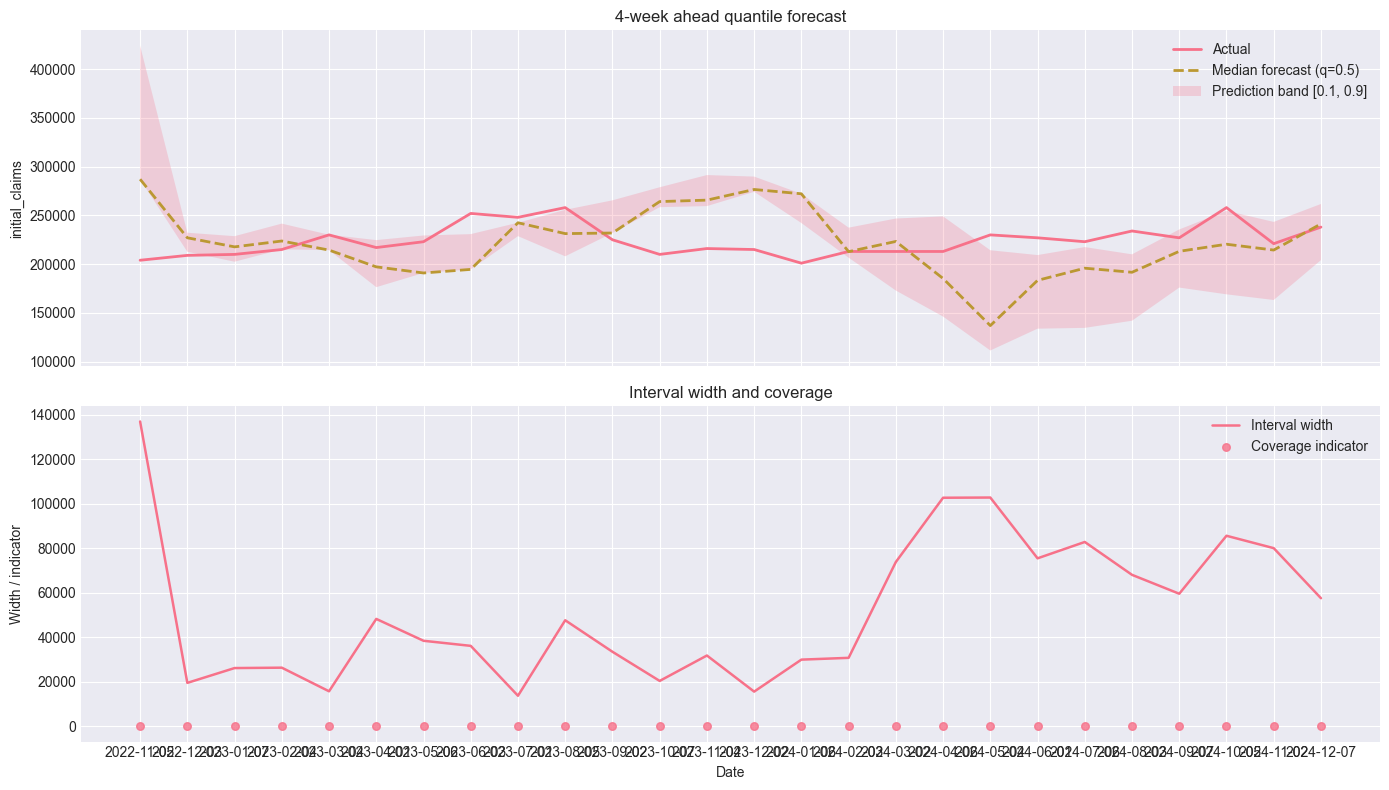

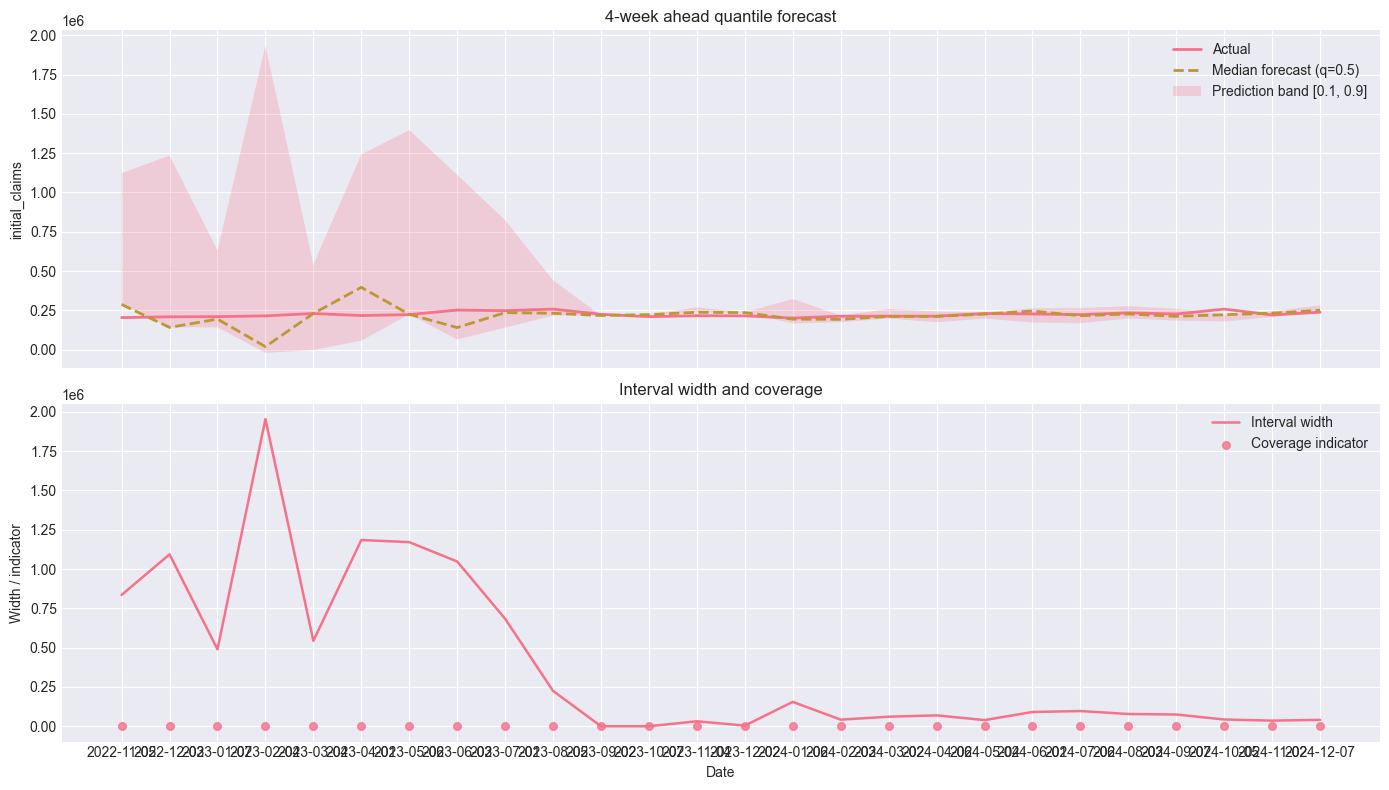

,3
pinball_q0_1_y_only,1.359727e+04
pinball_q0_5_y_only,1.583819e+04
pinball_q0_9_y_only,6.303677e+03
median_mae_y_only,3.167638e+04
median_rmse_y_only,4.065557e+04
median_mre_y_only,1.428627e+01
interval_coverage_y_only,3.846154e-01
avg_interval_width_y_only,5.229673e+04
horizon_weeks,4.000000e+00
n_forecasts,2.600000e+01


In [7]:
forecast_y_only = pd.read_csv(Y_ONLY_DIR / f"quantile_forecast_results_delta{INITIAL_CLAIMS_PLOT_HORIZON}.csv")
forecast_joint = pd.read_csv(JOINT_DIR / f"quantile_forecast_results_delta{INITIAL_CLAIMS_PLOT_HORIZON}.csv")

plot_quantile_forecast_interval(
    forecast_df=forecast_y_only,
    delta_t=INITIAL_CLAIMS_PLOT_HORIZON,
    target_label=TARGET_LABEL,
    path=PLOT_DIR / f"initial_claims_interval_y_only_delta{INITIAL_CLAIMS_PLOT_HORIZON}.png",
)

plot_quantile_forecast_interval(
    forecast_df=forecast_joint,
    delta_t=INITIAL_CLAIMS_PLOT_HORIZON,
    target_label=TARGET_LABEL,
    path=PLOT_DIR / f"initial_claims_interval_joint_delta{INITIAL_CLAIMS_PLOT_HORIZON}.png",
)

summary_table.loc[summary_table["horizon_weeks"] == INITIAL_CLAIMS_PLOT_HORIZON].T